# Импорты и вспомогательные функции

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict
from IPython.display import display, HTML

import umap
from scipy.spatial.distance import cdist
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import DBSCAN, KMeans
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.calibration import CalibratedClassifierCV

from catboost import CatBoostClassifier, CatBoostRegressor
from causalml.inference.tree import UpliftRandomForestClassifier
from sklift.datasets import fetch_x5
from sklift.models import TwoModels
import sklearn.utils
def dummy_check_matplotlib_support(*args, **kwargs):
    pass
sklearn.utils.check_matplotlib_support = dummy_check_matplotlib_support

from sklift.viz import plot_qini_curve, plot_uplift_curve

from sklift.metrics import (
    uplift_auc_score,
    qini_auc_score,
    weighted_average_uplift,
    uplift_at_k,
    uplift_by_percentile
)
from sklift.viz import plot_uplift_by_percentile

# Настройки графиков
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

import os
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))

if parent_dir not in os.sys.path:
    os.sys.path.append(parent_dir)

from helpers.feature_extraction_expanded import *
from helpers.classic_ml_models import *
from helpers.clusterization_features_extraction import *

In [4]:
# Фиксим вечную проблему sklift-модуля в визуализации графиков

import sklearn.utils
import sklift.viz.base as sklift_viz
import matplotlib.pyplot as plt

# Лечим проверку matplotlib
sklearn.utils.check_matplotlib_support = lambda *args, **kwargs: None

def patched_plot(self, auc_score=None, ax=None, name=None, title='AUC', **kwargs):
    if ax is None:
        _, ax = plt.subplots()

    display_name = name if name else getattr(self, 'estimator_name', None)
    
    label = f"{display_name} (AUC={auc_score:.4f})" if display_name else f"AUC={auc_score:.4f}"
    
    plot_kwargs = {k: v for k, v in kwargs.items() if k not in ['perfect', 'random']}
    
    # Рисуем основную линию
    ax.plot(self.x_actual, self.y_actual, label=label, linewidth=kwargs.get('lw', 2), **plot_kwargs)

    # Рисуем Random линию только один раз на весь график
    handles, labels = ax.get_legend_handles_labels()
    x_base = getattr(self, 'x_baseline', None)
    y_base = getattr(self, 'y_baseline', None)

    if x_base is not None and "Random" not in labels:
        ax.plot(x_base, y_base, label="Random", color="red", linestyle="--", linewidth=1.5, alpha=0.7)
    
    # Подписи осей в зависимости от масштаба
    if self.x_actual[-1] <= 1.1:
        ax.set_xlabel("Percent of population targeted")
        ax.set_ylabel("Incremental Outcome (Qini)")
    else:
        ax.set_xlabel("Number targeted")
        ax.set_ylabel("Cumulative Uplift")
    
    return self

# Перезаписываем метод
sklift_viz.UpliftCurveDisplay.plot = patched_plot

In [5]:
# У реализации sklift не получается связка с текущей версией numpy, которую мы поставили для работы causalml на UpliftTree, поэтому напишем собственные графики

def get_uplift_percentile_table(y_true, uplift_preds, treatment, bins=10):
    y_true = np.asarray(y_true).reshape(-1)
    uplift_preds = np.asarray(uplift_preds).reshape(-1)
    treatment = np.asarray(treatment).reshape(-1)

    df = uplift_by_percentile(
        y_true=y_true,
        uplift=uplift_preds,
        treatment=treatment,
        strategy='overall',
        bins=bins,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index()

    if 'index' in df.columns:
        df = df.rename(columns={'index': 'percentile'})

    # На всякий случай приводим к числам
    numeric_cols = [
        'n_treatment',
        'n_control',
        'response_rate_treatment',
        'response_rate_control',
        'uplift'
    ]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Стандартные ошибки для error bars
    p_t = df['response_rate_treatment'].to_numpy()
    p_c = df['response_rate_control'].to_numpy()
    n_t = df['n_treatment'].to_numpy()
    n_c = df['n_control'].to_numpy()

    se_t = np.sqrt(np.where(n_t > 0, p_t * (1 - p_t) / n_t, np.nan))
    se_c = np.sqrt(np.where(n_c > 0, p_c * (1 - p_c) / n_c, np.nan))
    se_u = np.sqrt(np.nan_to_num(se_t, nan=0.0) ** 2 + np.nan_to_num(se_c, nan=0.0) ** 2)

    df['se_treatment'] = se_t
    df['se_control'] = se_c
    df['se_uplift'] = se_u

    return df

def plot_percentile_grid(preds_dict, y_true, treatment, split_name, bins=10):
    model_names = list(preds_dict.keys())

    fig = plt.figure(figsize=(18, 14))
    outer = fig.add_gridspec(2, 2, wspace=0.22, hspace=0.28)

    for i, model_name in enumerate(model_names):
        row, col = divmod(i, 2)

        inner = outer[row, col].subgridspec(
            2, 1,
            height_ratios=[1, 1.05],
            hspace=0.18
        )

        ax_top = fig.add_subplot(inner[0])
        ax_bottom = fig.add_subplot(inner[1], sharex=ax_top)

        preds = preds_dict[model_name]
        df = get_uplift_percentile_table(
            y_true=y_true,
            uplift_preds=preds,
            treatment=treatment,
            bins=bins
        )

        wau = weighted_average_uplift(y_true, preds, treatment)

        x = np.arange(len(df))
        width = 0.36

        # Верхний график: uplift by percentile
        ax_top.bar(
            x,
            df['uplift'],
            yerr=df['se_uplift'],
            capsize=2,
            color='red',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='uplift'
        )
        ax_top.axhline(0, color='black', linewidth=1)

        ax_top.set_title(
            f'{model_name}\nUplift by percentile\nweighted average uplift = {wau:.4f}',
            fontsize=11,
            fontweight='bold'
        )
        ax_top.set_ylabel('Uplift = treatment response rate - control response rate', fontsize=10)
        ax_top.legend(loc='upper right', fontsize=9, frameon=True)
        ax_top.grid(axis='y', linestyle='--', alpha=0.35)
        ax_top.tick_params(axis='x', labelbottom=False)

        # Нижний график: response rate by percentile
        ax_bottom.bar(
            x - width / 2,
            df['response_rate_treatment'],
            width=width,
            yerr=df['se_treatment'],
            capsize=2,
            color='forestgreen',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='treatment\nresponse rate'
        )

        ax_bottom.bar(
            x + width / 2,
            df['response_rate_control'],
            width=width,
            yerr=df['se_control'],
            capsize=2,
            color='orange',
            alpha=0.95,
            edgecolor='black',
            linewidth=0.3,
            label='control\nresponse rate'
        )

        ax_bottom.set_title('Response rate by percentile', fontsize=11, fontweight='bold')
        ax_bottom.set_ylabel('response rate', fontsize=10)
        ax_bottom.set_xlabel('Percentile', fontsize=10)
        ax_bottom.set_xticks(x)
        ax_bottom.set_xticklabels(df['percentile'], rotation=35)
        ax_bottom.legend(loc='upper right', fontsize=9, frameon=True)
        ax_bottom.grid(axis='y', linestyle='--', alpha=0.35)

    fig.suptitle(f'Uplift by percentile | {split_name}', fontsize=16, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.985])
    plt.show()

In [6]:
def calculate_metrics(y_true, uplift_preds, treatment):
    return {
        "AUUC": uplift_auc_score(y_true, uplift_preds, treatment),
        "Qini": qini_auc_score(y_true, uplift_preds, treatment),
        "WAU": weighted_average_uplift(y_true, uplift_preds, treatment),
        "Uplift@10%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.1),
        "Uplift@20%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.2),
        "Uplift@30%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.3),
        "Uplift@50%": uplift_at_k(y_true, uplift_preds, treatment, strategy='overall', k=0.5)
    }

# Подготовка датасета

In [7]:
dataset = fetch_x5()
data = dataset.data

In [8]:
extractor = UpliftFeatureExtractorExpanded(drop_redundant=True)
df = extractor.calculate_features(
    clients_df=data.clients,
    train_df=data.train,
    treatment_df=dataset.treatment,
    target_df=dataset.target,
    purchases_df=data.purchases
)

del data, dataset
gc.collect()

features = extractor.feature_names
TARGET_COL = "target"
TREATMENT_COL = "treatment_flg"

X_all = df[features].copy()
y_all = df[TARGET_COL].values
t_all = df[TREATMENT_COL].values

print(f"Размер итогового датасета: {X_all.shape}")

Размер итогового датасета: (200039, 45)


In [9]:
strata_all = pd.Series(t_all).astype(str) + '_' + pd.Series(y_all).astype(str)

x_train_full, x_test_holdout, y_train_full, y_test_holdout, t_train_full, t_test_holdout = train_test_split(
    X_all,
    y_all,
    t_all,
    test_size=0.2,
    random_state=42,
    stratify=strata_all
)

print(x_train_full.shape, x_test_holdout.shape)

(160031, 45) (40008, 45)


In [10]:
current_num_cols = x_train_full.select_dtypes(include=['number']).columns.tolist()
clusterizer_full = UmapClusterTransformer(num_cols=current_num_cols, n_clusters=5)

x_train_full_clust = clusterizer_full.fit_transform(x_train_full)
x_test_holdout_clust = clusterizer_full.transform(x_test_holdout)

cat_cols_full = x_train_full_clust.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_full = x_train_full_clust.select_dtypes(include=['number']).columns.tolist()

# Модели для сравнения

In [49]:
test_holdout_preds = {}
test_results_list = []

In [50]:
# t-learner (для сравнения)
t_learner_full = build_t_learner_logreg(num_cols_full, cat_cols_full)
t_learner_full.estimator_trmnt = CalibratedClassifierCV(t_learner_full.estimator_trmnt, method='isotonic', cv=3)
t_learner_full.estimator_ctrl = CalibratedClassifierCV(t_learner_full.estimator_ctrl, method='isotonic', cv=3)

t_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)
preds_t_test = t_learner_full.predict(x_test_holdout_clust)

test_holdout_preds['T-Learner (LogReg)'] = preds_t_test
test_results_list.append({
    'Model': 'T-Learner (LogReg)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_t_test, t_test_holdout)
})

In [51]:
# x-learner (для сравнения)
x_learner_full = build_x_learner_catboost(cat_features=cat_cols_full, use_calibration=True)
x_learner_full.outcome_learner = CalibratedClassifierCV(x_learner_full.outcome_learner, method='isotonic', cv=3)
x_learner_full.propensity_learner = CalibratedClassifierCV(x_learner_full.propensity_learner, method='isotonic', cv=3)

x_learner_full.fit(x_train_full_clust, y_train_full, t_train_full)
preds_x_test = x_learner_full.predict(x_test_holdout_clust)

test_holdout_preds['X-Learner (CatBoost)'] = preds_x_test
test_results_list.append({
    'Model': 'X-Learner (CatBoost)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_x_test, t_test_holdout)
})

0:	learn: 0.6836937	total: 63.5ms	remaining: 9.28s
100:	learn: 0.5576336	total: 6.8s	remaining: 3.1s
146:	learn: 0.5552556	total: 9.92s	remaining: 0us
0:	learn: 0.6838014	total: 63.8ms	remaining: 9.31s
100:	learn: 0.5587178	total: 6.76s	remaining: 3.08s
146:	learn: 0.5562381	total: 9.86s	remaining: 0us
0:	learn: 0.6836975	total: 63.4ms	remaining: 9.25s
100:	learn: 0.5576685	total: 6.71s	remaining: 3.06s
146:	learn: 0.5550320	total: 9.74s	remaining: 0us
0:	learn: 0.6833008	total: 65.7ms	remaining: 9.59s
100:	learn: 0.5492651	total: 6.75s	remaining: 3.08s
146:	learn: 0.5462719	total: 9.83s	remaining: 0us
0:	learn: 0.6826693	total: 61.9ms	remaining: 9.04s
100:	learn: 0.5458117	total: 6.66s	remaining: 3.03s
146:	learn: 0.5428974	total: 9.69s	remaining: 0us
0:	learn: 0.6832889	total: 65.6ms	remaining: 9.58s
100:	learn: 0.5479387	total: 6.62s	remaining: 3.01s
146:	learn: 0.5448904	total: 9.65s	remaining: 0us
0:	learn: 0.4362808	total: 35ms	remaining: 5.11s
100:	learn: 0.4346279	total: 3.84s	

# Новая модель (TARNet + attention)

In [52]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.preprocessing import LabelEncoder


class TabularDataset(Dataset):
    def __init__(self, x_num, x_cat, y=None, t=None):
        self.x_num = torch.tensor(x_num, dtype=torch.float32)
        self.x_cat = torch.tensor(x_cat, dtype=torch.long)
        self.y = torch.tensor(y, dtype=torch.float32) if y is not None else None
        self.t = torch.tensor(t, dtype=torch.float32) if t is not None else None

    def __len__(self):
        return len(self.x_num)

    def __getitem__(self, idx):
        item = {'x_num': self.x_num[idx], 'x_cat': self.x_cat[idx]}
        if self.y is not None:
            item['y'] = self.y[idx]
        if self.t is not None:
            item['t'] = self.t[idx]
        return item


class NumericTokenizer(nn.Module):
    def __init__(self, n_num_features, d_model):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(n_num_features, d_model))
        self.biases = nn.Parameter(torch.zeros(n_num_features, d_model))

    def forward(self, x):
        return x.unsqueeze(-1) * self.weights + self.biases


class CategoricalTokenizer(nn.Module):
    def __init__(self, cardinalities, d_model):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(card + 1, d_model) for card in cardinalities
        ])

    def forward(self, x):
        return torch.stack([emb(x[:, i]) for i, emb in enumerate(self.embeddings)], dim=1)


class TARNetTransformer(nn.Module):
    def __init__(self, n_num_features, cardinalities, d_model=64, n_heads=4, n_layers=3, mlp_hidden=128, dropout=0.1):
        super().__init__()

        self.num_tokenizer = NumericTokenizer(n_num_features, d_model)
        self.cat_tokenizer = CategoricalTokenizer(cardinalities, d_model)

        self.cls_token = nn.Parameter(torch.randn(1, 1, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=d_model * 4,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        self.treatment_head = nn.Sequential(
            nn.Linear(d_model, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )

        self.control_head = nn.Sequential(
            nn.Linear(d_model, mlp_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden, 1)
        )

    def forward(self, x_num, x_cat):
        tokens_num = self.num_tokenizer(x_num)
        tokens_cat = self.cat_tokenizer(x_cat)
        tokens = torch.cat([tokens_num, tokens_cat], dim=1)

        cls = self.cls_token.expand(tokens.size(0), -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)

        shared = self.transformer(tokens)
        cls_repr = shared[:, 0, :]

        p_treatment = torch.sigmoid(self.treatment_head(cls_repr)).squeeze(-1)
        p_control = torch.sigmoid(self.control_head(cls_repr)).squeeze(-1)

        return p_treatment, p_control


class TARNetUpliftClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        num_cols,
        cat_cols,
        d_model=64,
        n_heads=4,
        n_layers=3,
        mlp_hidden=128,
        dropout=0.1,
        lr=1e-3,
        n_epochs=20,
        batch_size=512,
        device=None
    ):
        self.num_cols = num_cols
        self.cat_cols = cat_cols
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_layers = n_layers
        self.mlp_hidden = mlp_hidden
        self.dropout = dropout
        self.lr = lr
        self.n_epochs = n_epochs
        self.batch_size = batch_size
        self.device = device or ('cuda' if torch.cuda.is_available() else 'cpu')

        print(f"Device: {self.device}")

    def _prepare_data(self, X, y=None, t=None):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()

        x_num = X[self.num_cols].fillna(0).values.astype(np.float32)

        x_cat = np.zeros((len(X), len(self.cat_cols)), dtype=np.int64)
        for i, col in enumerate(self.cat_cols):
            le = self.label_encoders_[col]
            vals = X[col].astype(str).values
            x_cat[:, i] = np.array([
                le.transform([v])[0] if v in le.classes_ else 0
                for v in vals
            ])

        return x_num, x_cat

    def fit(self, X, y, t):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()

        self.label_encoders_ = {}
        for col in self.cat_cols:
            le = LabelEncoder()
            le.fit(X[col].astype(str).values)
            self.label_encoders_[col] = le

        cardinalities = [len(self.label_encoders_[col].classes_) for col in self.cat_cols]

        self.scaler_ = StandardScaler()
        X[self.num_cols] = self.scaler_.fit_transform(X[self.num_cols].fillna(0))

        x_num, x_cat = self._prepare_data(X)

        self.model_ = TARNetTransformer(
            n_num_features=len(self.num_cols),
            cardinalities=cardinalities,
            d_model=self.d_model,
            n_heads=self.n_heads,
            n_layers=self.n_layers,
            mlp_hidden=self.mlp_hidden,
            dropout=self.dropout
        ).to(self.device)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=self.lr, weight_decay=1e-4)
        dataset = TabularDataset(x_num, x_cat, y, t)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=True, pin_memory=True)

        self.model_.train()
        for epoch in range(self.n_epochs):
            total_loss = 0
            for batch in loader:
                x_n = batch['x_num'].to(self.device)
                x_c = batch['x_cat'].to(self.device)
                y_b = batch['y'].to(self.device)
                t_b = batch['t'].to(self.device)

                p_t, p_c = self.model_(x_n, x_c)

                loss_t = F.binary_cross_entropy(p_t[t_b == 1], y_b[t_b == 1]) if (t_b == 1).any() else 0
                loss_c = F.binary_cross_entropy(p_c[t_b == 0], y_b[t_b == 0]) if (t_b == 0).any() else 0
                loss = loss_t + loss_c

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                total_loss += loss.item()

            print(f"Epoch {epoch+1}/{self.n_epochs} | Loss: {total_loss/len(loader):.4f}")

        return self

    def predict(self, X):
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X.copy()
        X[self.num_cols] = self.scaler_.transform(X[self.num_cols].fillna(0))
        x_num, x_cat = self._prepare_data(X)

        dataset = TabularDataset(x_num, x_cat)
        loader = DataLoader(dataset, batch_size=self.batch_size, shuffle=False)

        self.model_.eval()
        p_ts, p_cs = [], []
        with torch.no_grad():
            for batch in loader:
                x_n = batch['x_num'].to(self.device)
                x_c = batch['x_cat'].to(self.device)
                p_t, p_c = self.model_(x_n, x_c)
                p_ts.append(p_t.cpu().numpy())
                p_cs.append(p_c.cpu().numpy())

        p_t_all = np.concatenate(p_ts)
        p_c_all = np.concatenate(p_cs)
        return p_t_all - p_c_all


In [53]:
tarnet_full = TARNetUpliftClassifier(
    num_cols=num_cols_full,
    cat_cols=cat_cols_full,
    d_model=32,
    n_heads=4,
    n_layers=2,
    mlp_hidden=64,
    dropout=0.2,
    lr=5e-4,
    n_epochs=50,
    batch_size=1024
)

tarnet_full.fit(x_train_full_clust, y_train_full, t_train_full)
preds_tarnet_test = tarnet_full.predict(x_test_holdout_clust)

test_holdout_preds['TARNet (with attention)'] = preds_tarnet_test
test_results_list.append({
    'Model': 'TARNet (with attention)',
    'Split': 'test_holdout',
    **calculate_metrics(y_test_holdout, preds_tarnet_test, t_test_holdout)
})

Device: cuda
Epoch 1/50 | Loss: 1.2019
Epoch 2/50 | Loss: 1.1319
Epoch 3/50 | Loss: 1.1243
Epoch 4/50 | Loss: 1.1216
Epoch 5/50 | Loss: 1.1205
Epoch 6/50 | Loss: 1.1171
Epoch 7/50 | Loss: 1.1161
Epoch 8/50 | Loss: 1.1156
Epoch 9/50 | Loss: 1.1146
Epoch 10/50 | Loss: 1.1141
Epoch 11/50 | Loss: 1.1123
Epoch 12/50 | Loss: 1.1115
Epoch 13/50 | Loss: 1.1124
Epoch 14/50 | Loss: 1.1111
Epoch 15/50 | Loss: 1.1100
Epoch 16/50 | Loss: 1.1106
Epoch 17/50 | Loss: 1.1102
Epoch 18/50 | Loss: 1.1106
Epoch 19/50 | Loss: 1.1088
Epoch 20/50 | Loss: 1.1095
Epoch 21/50 | Loss: 1.1088
Epoch 22/50 | Loss: 1.1094
Epoch 23/50 | Loss: 1.1080
Epoch 24/50 | Loss: 1.1082
Epoch 25/50 | Loss: 1.1078
Epoch 26/50 | Loss: 1.1072
Epoch 27/50 | Loss: 1.1073
Epoch 28/50 | Loss: 1.1076
Epoch 29/50 | Loss: 1.1077
Epoch 30/50 | Loss: 1.1068
Epoch 31/50 | Loss: 1.1075
Epoch 32/50 | Loss: 1.1063
Epoch 33/50 | Loss: 1.1061
Epoch 34/50 | Loss: 1.1064
Epoch 35/50 | Loss: 1.1061
Epoch 36/50 | Loss: 1.1070
Epoch 37/50 | Loss: 1.10

# Метрики

In [54]:
test_results_df = pd.DataFrame(test_results_list)
display(test_results_df)

,Model,Split,AUUC,Qini,WAU,Uplift@10%,Uplift@20%,Uplift@30%,Uplift@50%
0,T-Learner (LogReg),test_holdout,0.020980,0.013562,0.033354,0.108997,0.085635,0.066872,0.048509
1,X-Learner (CatBoost),test_holdout,0.022170,0.014521,0.034218,0.108933,0.079364,0.068743,0.046739
2,TARNet (with attention),test_holdout,0.016415,0.010741,0.034156,0.107018,0.070142,0.057514,0.042714


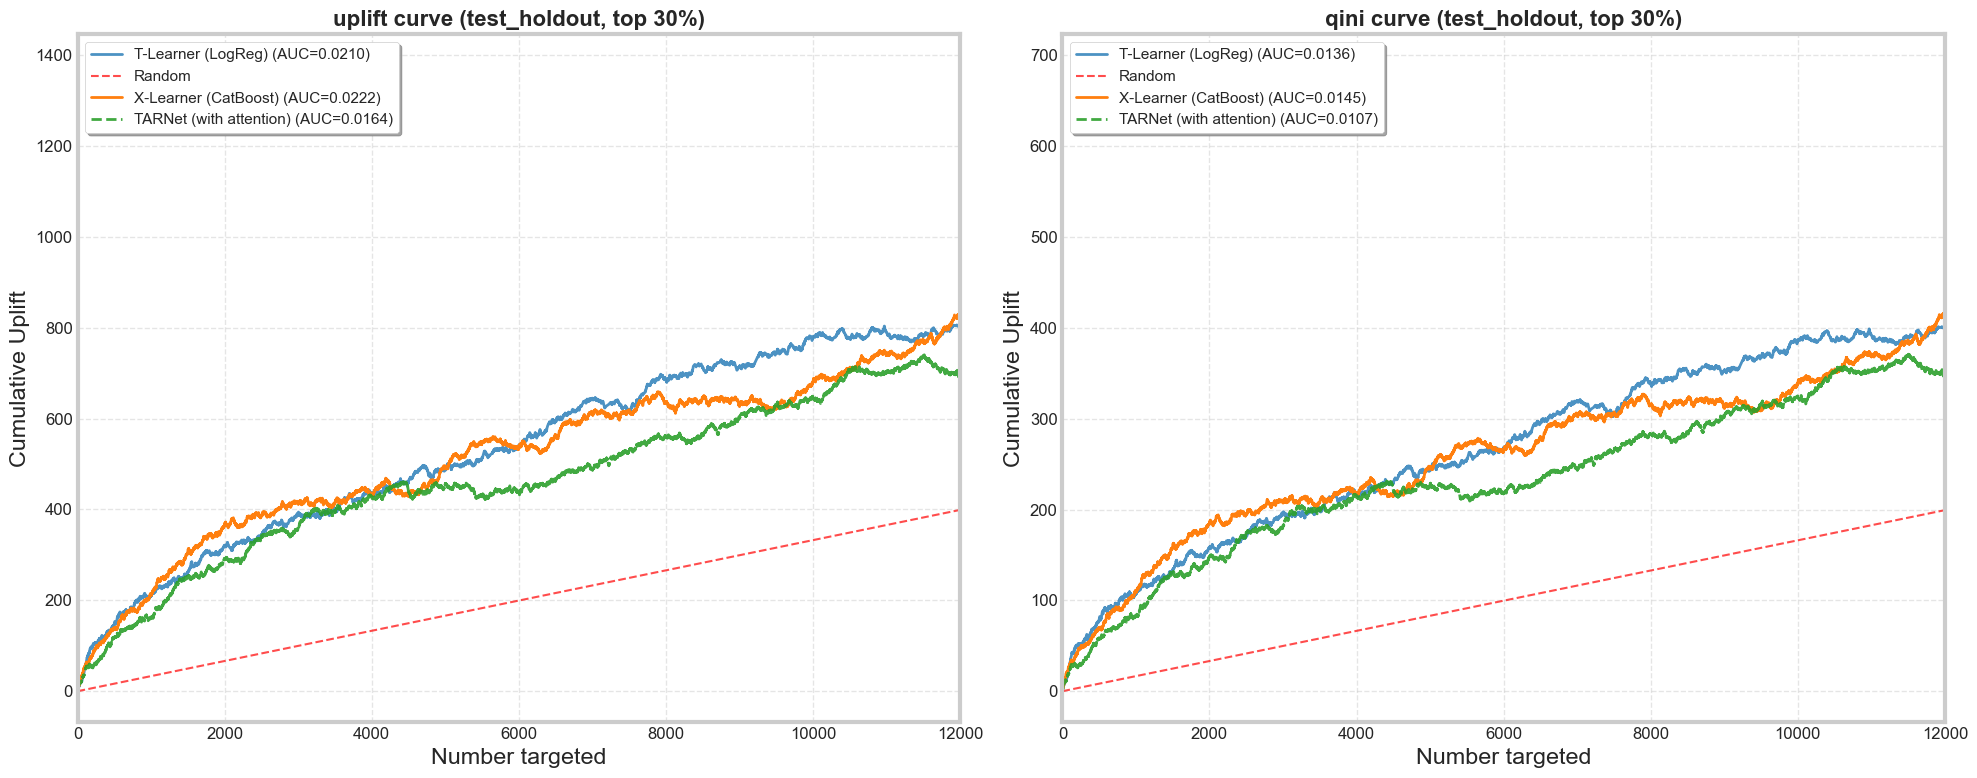

In [55]:
top_k_percent = 0.3

model_colors = {
    "T-Learner (LogReg)": "#1f77b4",
    "TARNet (with attention)": "#2ca02c",
    "X-Learner (CatBoost)": "#ff7f0e"
}

model_styles = {
    "T-Learner (LogReg)": {"ls": "-", "alpha": 0.8},
    "TARNet (with attention)": {"ls": "--", "alpha": 0.9},
    "X-Learner (CatBoost)": {"ls": "-", "alpha": 1.0}
}

split_specs = {
    "test_holdout": {
        "y": y_test_holdout,
        "t": t_test_holdout,
        "preds_dict": test_holdout_preds
    }
}

for split_name, split_data in split_specs.items():
    y_split = split_data["y"]
    t_split = split_data["t"]
    preds_dict = split_data["preds_dict"]

    max_x = int(len(y_split) * top_k_percent)

    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    for model_name, preds in preds_dict.items():
        style = model_styles.get(model_name, {"ls": "-", "alpha": 0.8})
        color = model_colors.get(model_name, "gray")

        plot_uplift_curve(
            y_split,
            preds,
            t_split,
            name=model_name,
            ax=axes[0],
            color=color,
            perfect=False,
            **style
        )

        plot_qini_curve(
            y_split,
            preds,
            t_split,
            name=model_name,
            ax=axes[1],
            color=color,
            perfect=False,
            **style
        )

    axes[0].set_title(f"uplift curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')
    axes[1].set_title(f"qini curve ({split_name}, top 30%)", fontsize=16, fontweight='bold')

    for ax in axes:
        ax.set_xlim(0, max_x)
        ax.legend(loc='upper left', fontsize=11, frameon=True, shadow=True)
        ax.grid(True, which='both', linestyle='--', alpha=0.5)
        ax.tick_params(axis='both', which='major', labelsize=12)

    plt.tight_layout()
    plt.show()

In [56]:
percentile_frames = []

for model_name, preds in test_holdout_preds.items():
    df_test_pct = uplift_by_percentile(
        y_true=y_test_holdout,
        uplift=preds,
        treatment=t_test_holdout,
        strategy='overall',
        bins=10,
        std=False,
        total=False,
        string_percentiles=True
    ).reset_index().rename(columns={'index': 'percentile'})

    df_test_pct['Model'] = model_name
    df_test_pct['Split'] = 'test_holdout'
    percentile_frames.append(df_test_pct)

all_percentiles_df = pd.concat(percentile_frames, ignore_index=True)

for col in ['n_treatment', 'n_control']:
    all_percentiles_df[col] = all_percentiles_df[col].round().astype('Int64')

all_percentiles_df['n_total'] = all_percentiles_df['n_treatment'] + all_percentiles_df['n_control']

In [57]:
split_name = 'test_holdout'

split_percentiles_df = all_percentiles_df[all_percentiles_df['Split'] == split_name].copy()

pivot_uplift = split_percentiles_df.pivot(index='percentile', columns='Model', values='uplift').reset_index()
pivot_n_treat = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_treatment').reset_index()
pivot_n_ctrl = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_control').reset_index()
pivot_n_total = split_percentiles_df.pivot(index='percentile', columns='Model', values='n_total').reset_index()

display_df = pivot_uplift.copy()
display_df = display_df.rename(columns={'percentile': 'Перцентиль (бакет)'})
model_columns = [col for col in display_df.columns if col != 'Перцентиль (бакет)']

for model in model_columns:
    display_df[model] = (
        pivot_uplift[model].apply(lambda x: f'{x:+.2%}' if pd.notna(x) else 'nan')
        + '\n' +
        'n=' + pivot_n_total[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', t=' + pivot_n_treat[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
        + ', c=' + pivot_n_ctrl[model].apply(lambda x: f'{int(x)}' if pd.notna(x) else 'nan')
    )

gmap_df = pivot_uplift[model_columns].copy()
gmap_df.index = display_df.index

styled_df = (
    display_df.style
    .background_gradient(
        cmap='RdYlGn',
        subset=model_columns,
        gmap=gmap_df,
        vmin=-0.05,
        vmax=0.05,
        axis=None
    )
    .set_properties(**{
        'text-align': 'center',
        'border': '1px solid black',
        'white-space': 'pre-line'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('text-align', 'center'),
                ('background-color', '#ff7f0e'),
                ('border', '1px solid black')
            ]
        }
    ])
    .hide(axis='index')
)

display(styled_df)

Перцентиль (бакет),T-Learner (LogReg),TARNet (with attention),X-Learner (CatBoost)
0-10,"+10.87% n=4001, t=1998, c=2003","+10.67% n=4001, t=2004, c=1997","+10.87% n=4001, t=2011, c=1990"
10-20,"+6.33% n=4001, t=1954, c=2047","+3.32% n=4001, t=2032, c=1969","+5.08% n=4001, t=1960, c=2041"
20-30,"+2.83% n=4001, t=2029, c=1972","+3.26% n=4001, t=1984, c=2017","+4.60% n=4001, t=2039, c=1962"
30-40,"+1.05% n=4001, t=2019, c=1982","+3.29% n=4001, t=2008, c=1993","+0.18% n=4001, t=2021, c=1980"
40-50,"+2.77% n=4001, t=2041, c=1960","+0.82% n=4001, t=2006, c=1995","+2.41% n=4001, t=2038, c=1963"
50-60,"+0.29% n=4001, t=1978, c=2023","+2.89% n=4001, t=2020, c=1981","+3.88% n=4001, t=2021, c=1980"
60-70,"+1.34% n=4001, t=2007, c=1994","+0.87% n=4001, t=1962, c=2039","+2.67% n=4001, t=1948, c=2053"
70-80,"+3.46% n=4001, t=1999, c=2002","+4.46% n=4001, t=2048, c=1953","+0.83% n=4001, t=2039, c=1962"
80-90,"+2.59% n=4000, t=1970, c=2030","+2.71% n=4000, t=1955, c=2045","+1.54% n=4000, t=1982, c=2018"
90-100,"+1.89% n=4000, t=2001, c=1999","+1.76% n=4000, t=1977, c=2023","+2.16% n=4000, t=1937, c=2063"


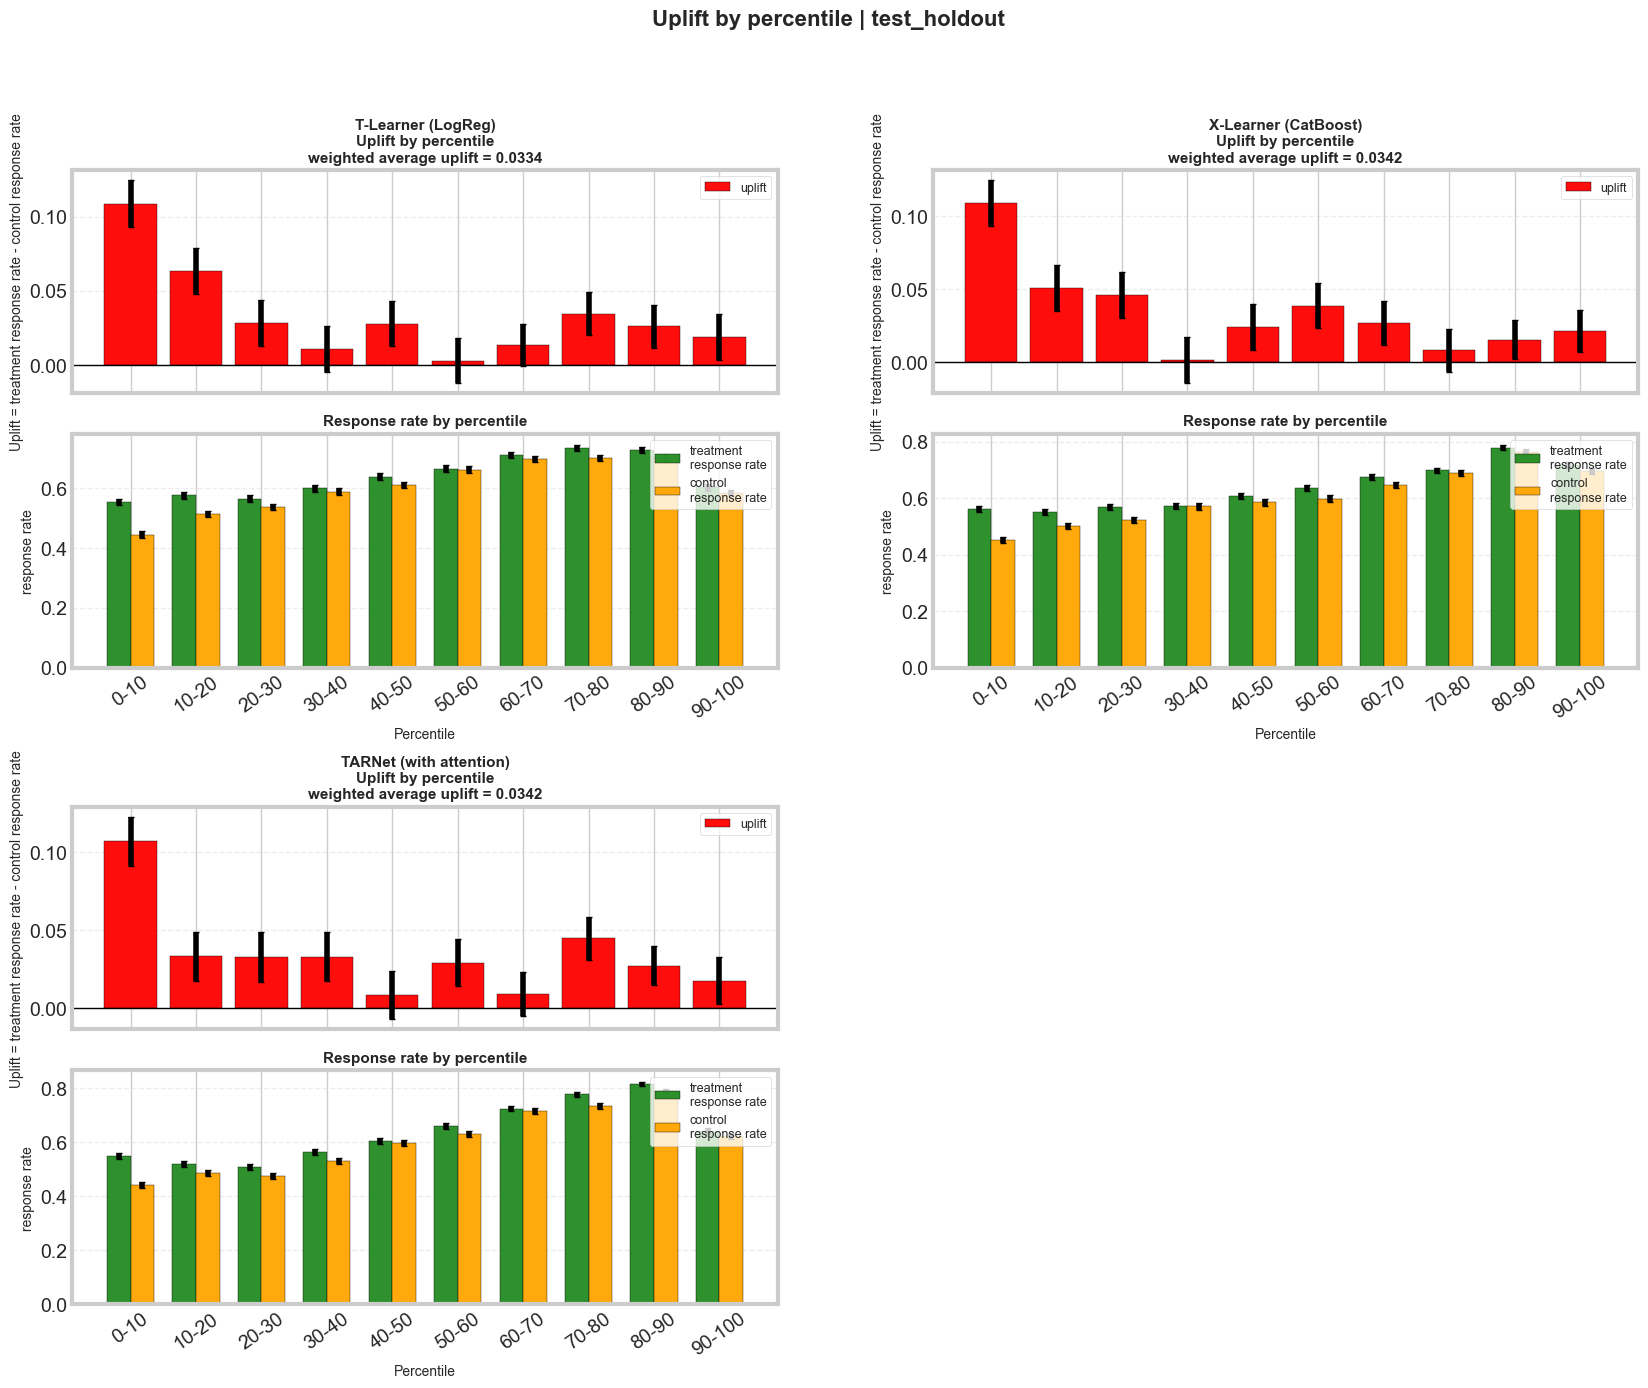

In [58]:
plot_percentile_grid(
    preds_dict=test_holdout_preds,
    y_true=y_test_holdout,
    treatment=t_test_holdout,
    split_name='test_holdout',
    bins=10
)

# Вывод

DL подход (TARNet с attention) на табличных данных ожидаемо не дал прироста метрик.